In [1]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from plot_functions import *
from comparison_functions import *

In [2]:
#import classy as classy_pp
import classy_NEDE_Magnus as classy_Magnus
import classy_NEDE_Tobias as classy_Tobias
import classy_DRMD as classy_reference

In [3]:
model_Magnus = run_cosmo(classy_Magnus, get_dict_general())
model_Tobias = run_cosmo(classy_Tobias, get_dict_general_pp())
model_reference = run_cosmo(classy_reference, get_dict_general())

DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=0 flag_int=0  Nstd_in=0 Nint_in=0  => Nstd=0 Nint=0 Ntot=0 (local N_ncdm=0)


In [4]:
from scipy.interpolate import interp1d

# Load backgrounds
background_Magnus = model_Magnus.get_background()
background_Tobias = model_Tobias.get_background()
background_reference = model_reference.get_background()

print(background_Magnus['z'])
print(background_Tobias['z'])

[1.00000000e+14 9.99194400e+13 9.98389448e+13 ... 1.61314959e-03
 8.06249775e-04 0.00000000e+00]
[1.00000000e+14 9.99300219e+13 9.98600928e+13 ... 1.40103227e-03
 7.00270945e-04 0.00000000e+00]


In [5]:

from scipy.interpolate import interp1d

# Load backgrounds
background_Magnus = model_Magnus.get_background()
background_Tobias = model_Tobias.get_background()
background_reference = model_reference.get_background()

print(background_Magnus['(.)rho_crit'])


failed_tests = {}


# 1. Define the Common Grid (Independent Variable)
# We use the Magnus z-array as the "master" grid since it has higher resolution (40000 pts)
z_master = background_Magnus['z']
z_tobias = background_Tobias['z']

# Note: interp1d requires the x-axis to be strictly increasing. 
# CLASS sometimes outputs z from high to low. We sort just to be safe.
if z_tobias[0] > z_tobias[-1]:
    z_tobias = np.flip(z_tobias)
    # We must also flip the data arrays later when interpolating

if z_master[0] > z_master[-1]:
    z_master = np.flip(z_master)

# 2. Iterate and Compare
for key in background_reference.keys():
    # Skip the independent variable itself
    if key == 'z':
        continue
    
    # --- Prepare Data ---
    val_magnus = background_Magnus[key]
    val_ref = background_reference[key]
    val_tobias_raw = background_Tobias[key]
    
    # Handle flipping for Tobias data if z was decreasing
    if background_Tobias['z'][0] > background_Tobias['z'][-1]:
        val_tobias_raw = np.flip(val_tobias_raw)

    if background_Magnus['z'][0] > background_Magnus['z'][-1]:
        val_magnus = np.flip(val_magnus)
        val_ref = np.flip(val_ref)

    # --- Interpolation ---
    # Create a function f(z) = y based on Tobias's data
    # 'cubic' is generally safer for smooth cosmological functions than 'linear'
    f_interp = interp1d(z_tobias, val_tobias_raw, kind='cubic', 
                        bounds_error=False, fill_value="extrapolate")
    
    # Evaluate Tobias's model on the Master (Magnus) grid
    val_tobias_interp = f_interp(z_master)

    # --- Comparison ---
    # We use np.all() because np.isclose returns an array of booleans
    # We also check if shapes match now (they should)
    
    # Compare Magnus vs Tobias (Interpolated)
    match_tobias = np.all(np.isclose(val_magnus, val_tobias_interp, rtol=1e-5, atol=1e-8))
    
    # Compare Magnus vs Reference (Assuming they have same length/grid)
    # If Reference also has a different grid, you must interpolate it too.
    # Assuming Reference is exactly like Magnus here:
    match_ref = np.all(np.isclose(val_magnus, val_ref, rtol=1e-5, atol=1e-8))

    if match_tobias and match_ref:
        print(f"✓ {key}: Consistent across all models.")
    else:
        # Calculate max relative difference for debugging
        diff = np.abs((val_magnus - val_tobias_interp) / (val_magnus + 1e-30))
        max_diff = np.max(diff)
        print(f"X {key}: Differs. (Max Rel Diff: {max_diff:.2e})")
        failed_tests[key] = {
            'max_rel_diff': max_diff,
            'val_magnus': val_magnus,
            'val_tobias_interp': val_tobias_interp,
            'val_ref': val_ref
        }

[4.02185631e+44 4.00891192e+44 3.99600920e+44 ... 5.07717291e-08
 5.07333773e-08 5.06951182e-08]
X proper time [Gyr]: Differs. (Max Rel Diff: 3.25e-03)
X conf. time [Mpc]: Differs. (Max Rel Diff: 1.41e-03)
X H [1/Mpc]: Differs. (Max Rel Diff: 7.41e-03)
X comov. dist.: Differs. (Max Rel Diff: 7.46e-03)
X ang.diam.dist.: Differs. (Max Rel Diff: 7.46e-03)
X lum. dist.: Differs. (Max Rel Diff: 7.46e-03)
X comov.snd.hrz.: Differs. (Max Rel Diff: 4.54e-04)
✓ (.)rho_g: Consistent across all models.
✓ (.)rho_b: Consistent across all models.
✓ (.)rho_cdm: Consistent across all models.
✓ (.)rho_lambda: Consistent across all models.
✓ (.)rho_ur: Consistent across all models.
✓ (.)rho_crit: Consistent across all models.
✓ (.)rho_tot: Consistent across all models.
✓ (.)p_tot: Consistent across all models.
✓ (.)p_tot_prime: Consistent across all models.
X gr.fac. D: Differs. (Max Rel Diff: 3.44e-03)
X gr.fac. f: Differs. (Max Rel Diff: 8.42e-03)


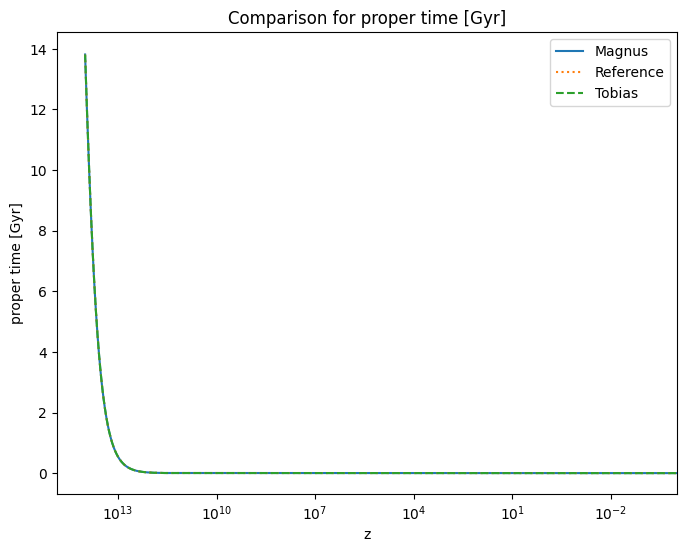

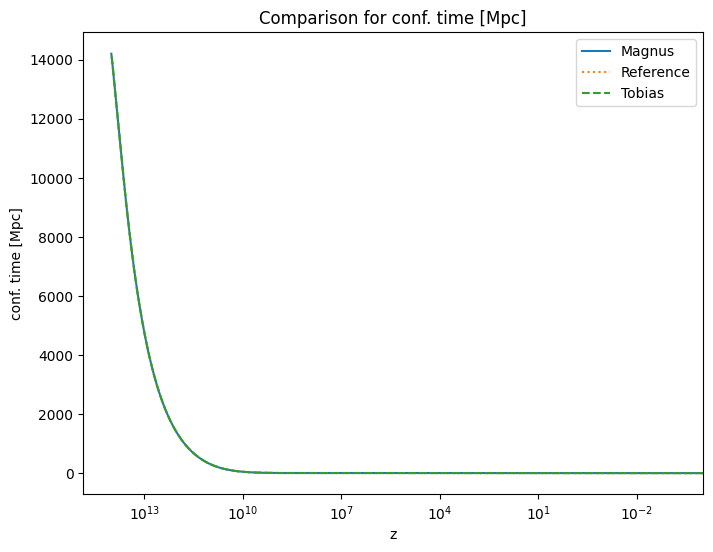

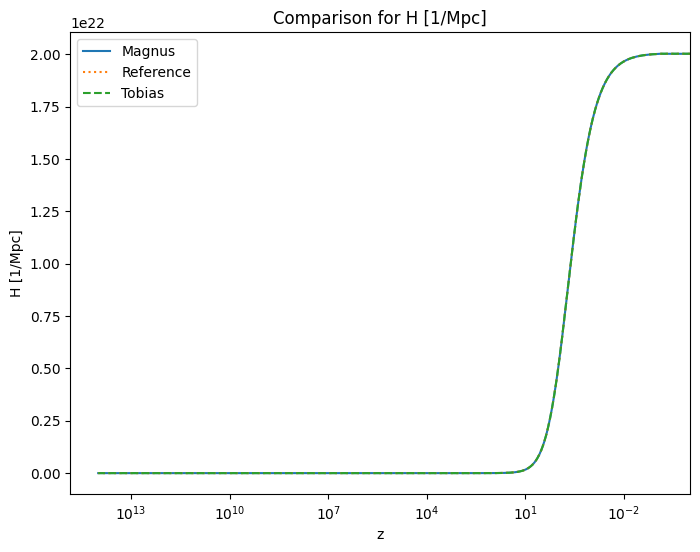

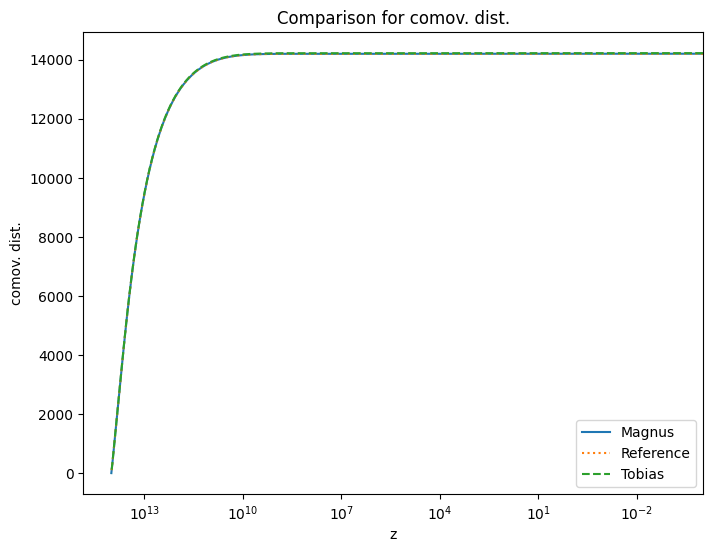

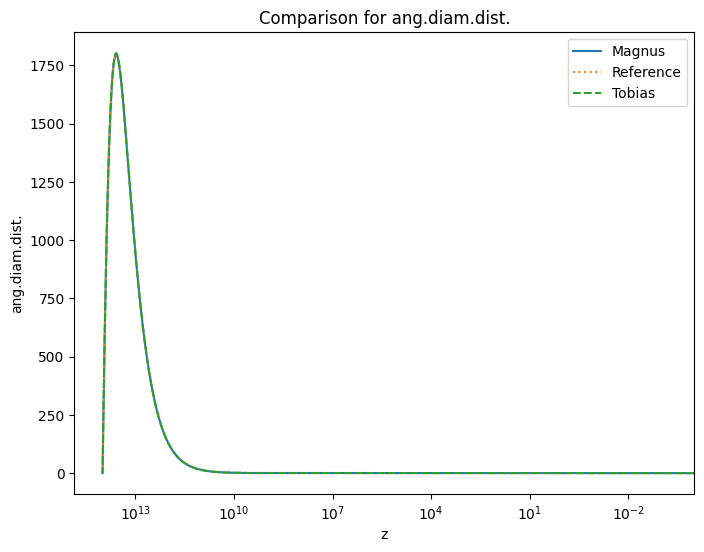

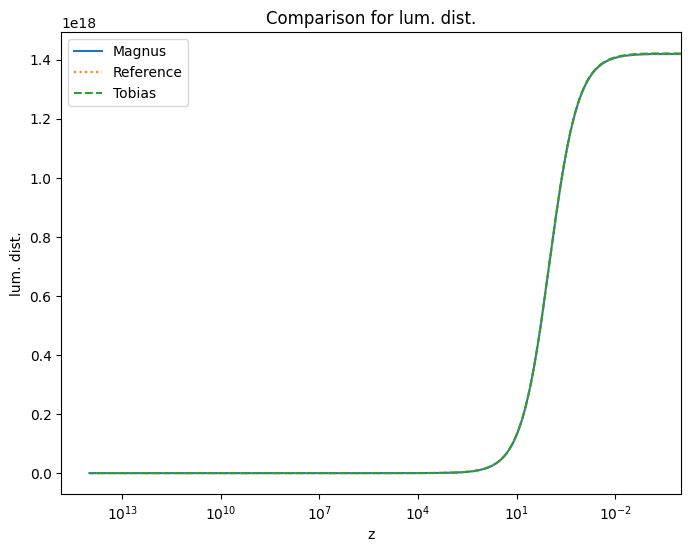

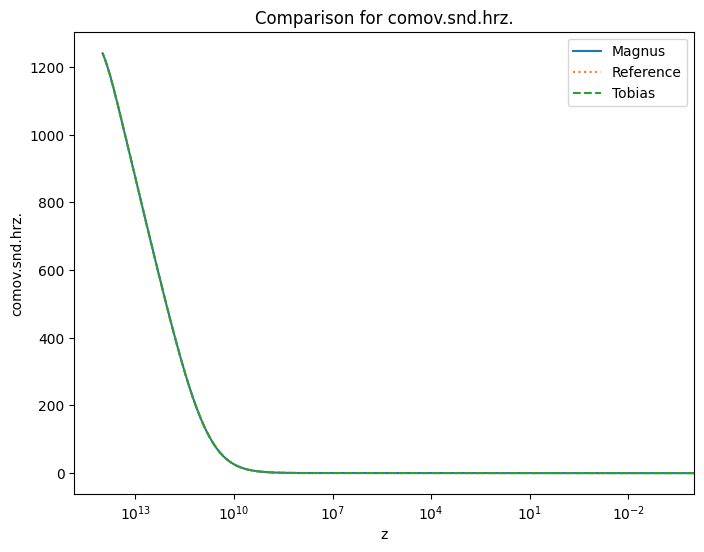

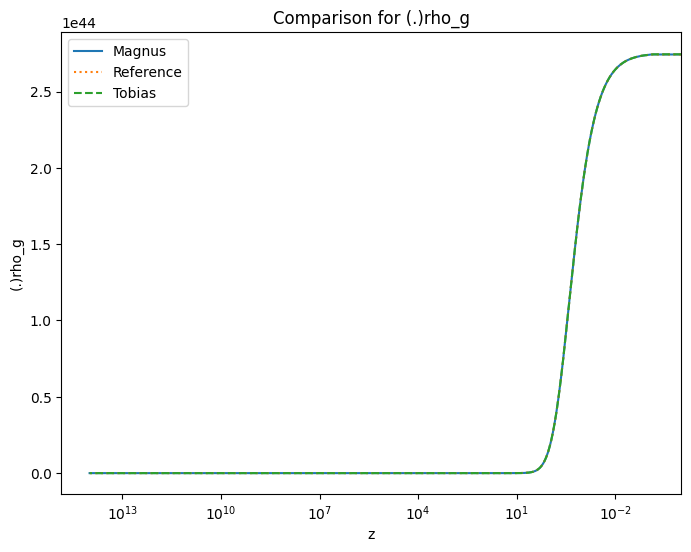

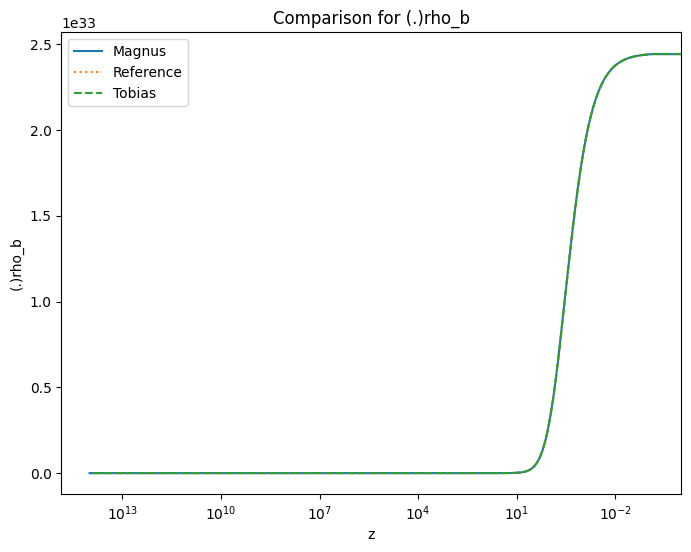

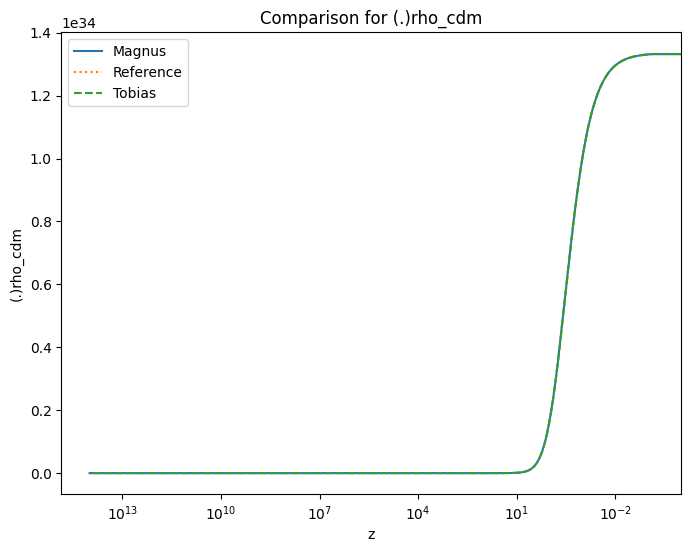

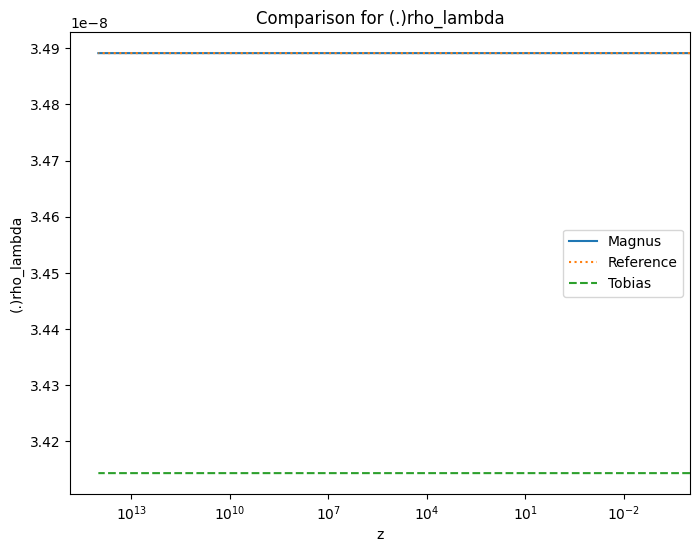

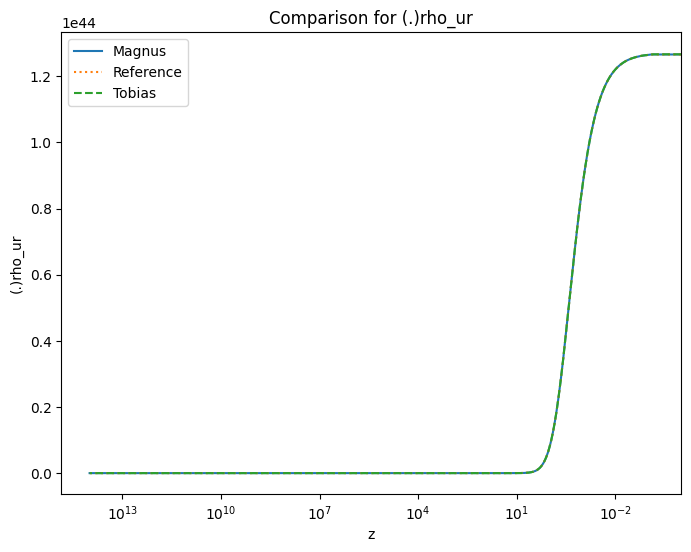

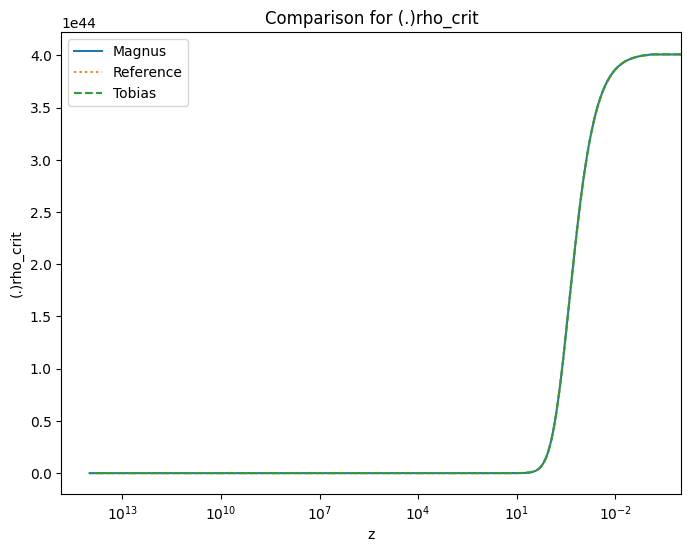

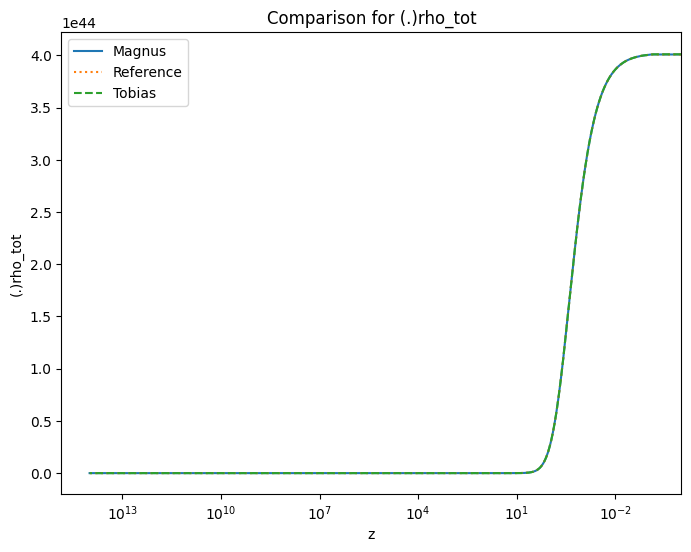

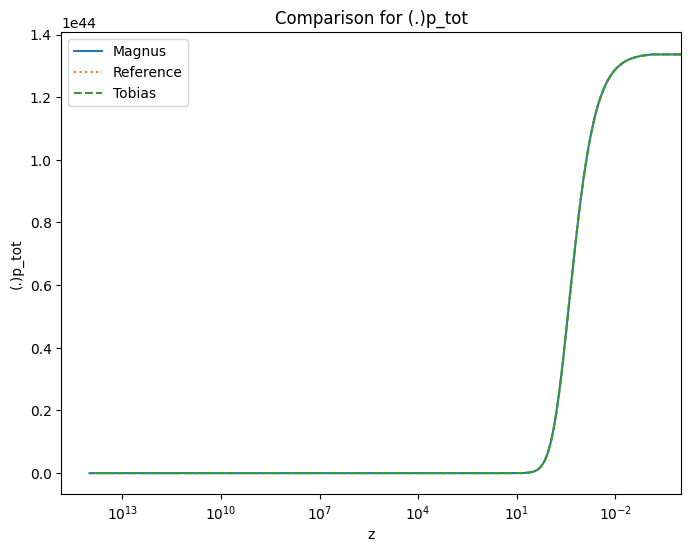

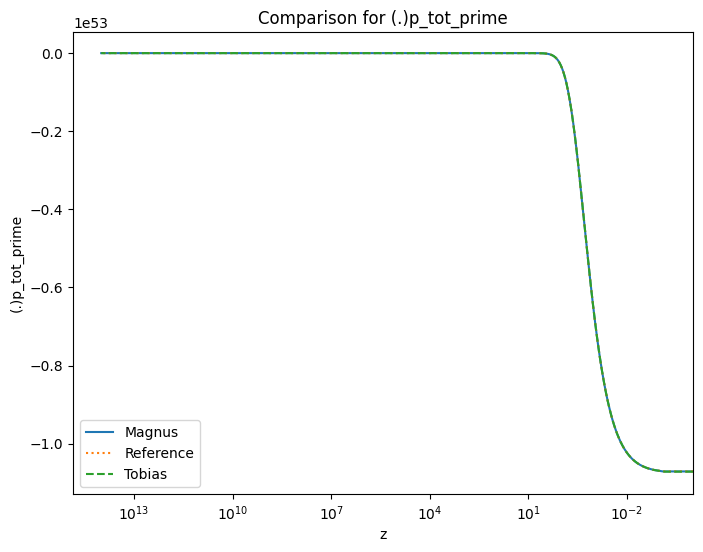

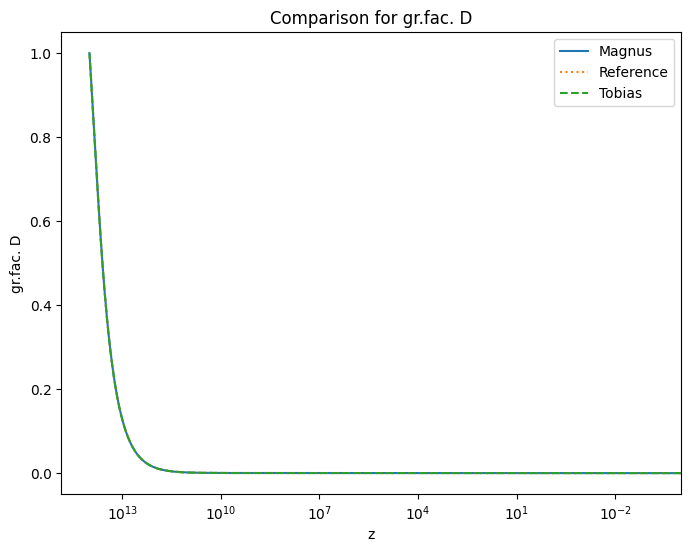

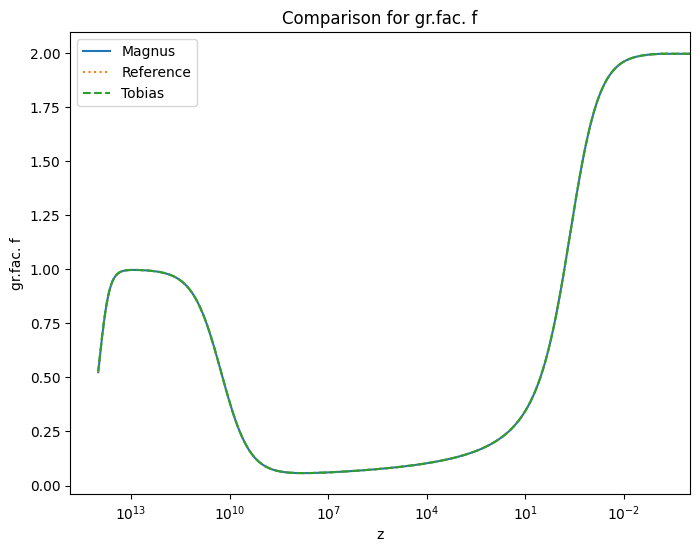

In [6]:
for key in background_Magnus.keys():
    if key == 'z':
        continue
    

    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(z_master, background_Magnus[key], label='Magnus', ls='solid')
    ax.plot(z_master, background_reference[key], label='Reference', ls='dotted')
    ax.plot(z_tobias, background_Tobias[key], label='Tobias', ls='dashed')
    ax.set(xlabel='z', ylabel=key, xscale='log')
    ax.invert_xaxis()  # Invert x-axis to have z decreasing from left to right
    ax.set_title(f'Comparison for {key}')
    ax.legend()

Failed test: proper time [Gyr]
Max Relative Difference: 3.25e-03
Failed test: conf. time [Mpc]
Max Relative Difference: 1.41e-03
Failed test: H [1/Mpc]
Max Relative Difference: 7.41e-03
Failed test: comov. dist.
Max Relative Difference: 7.46e-03
Failed test: ang.diam.dist.
Max Relative Difference: 7.46e-03
Failed test: lum. dist.
Max Relative Difference: 7.46e-03
Failed test: comov.snd.hrz.
Max Relative Difference: 4.54e-04
Failed test: gr.fac. D
Max Relative Difference: 3.44e-03
Failed test: gr.fac. f
Max Relative Difference: 8.42e-03


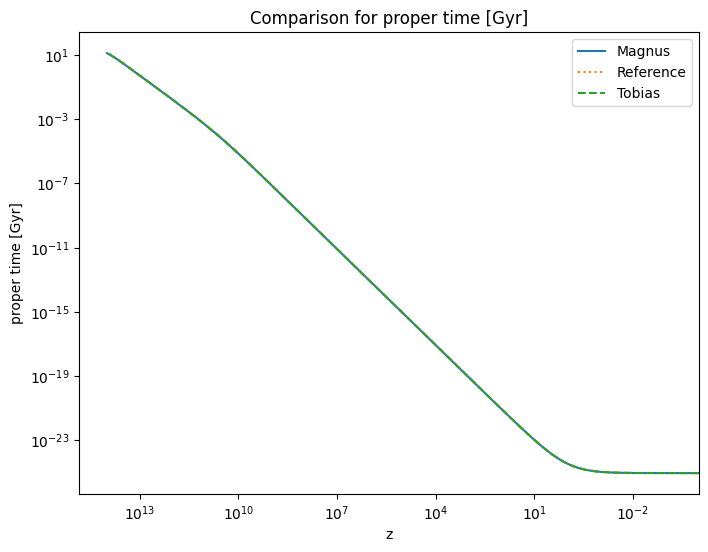

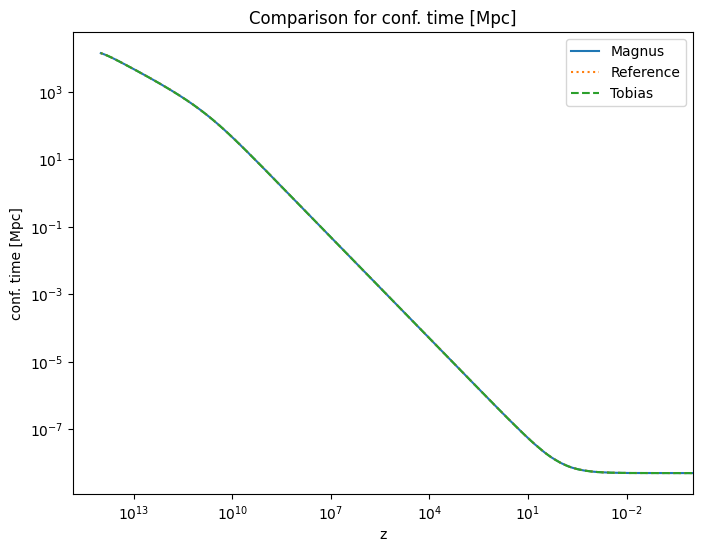

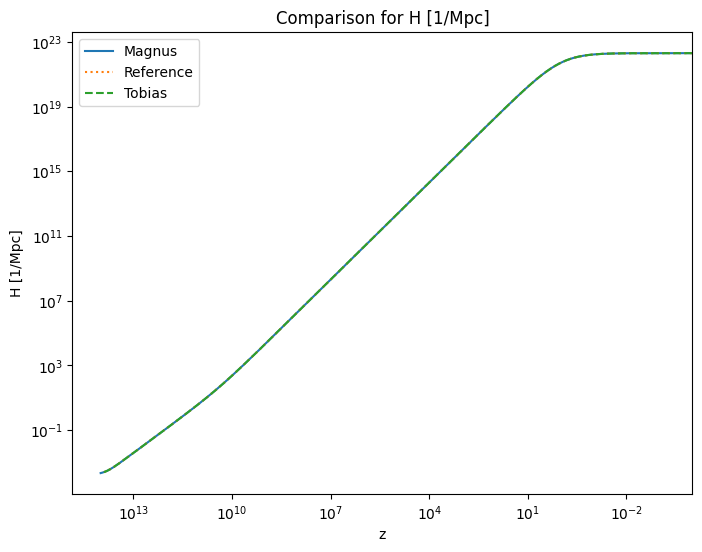

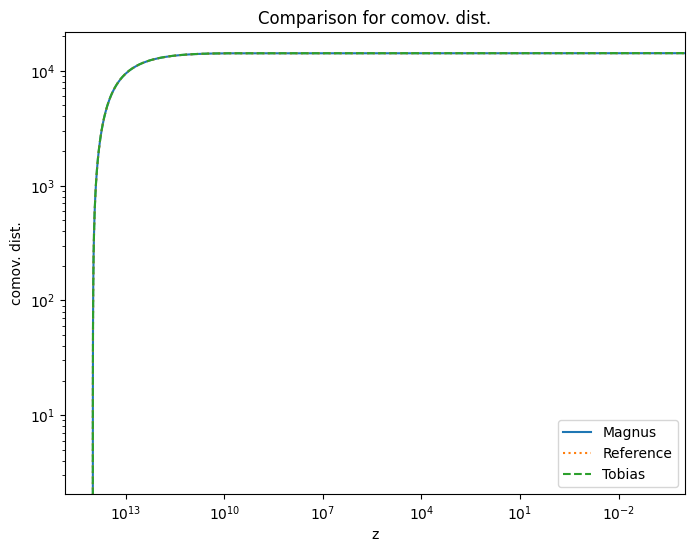

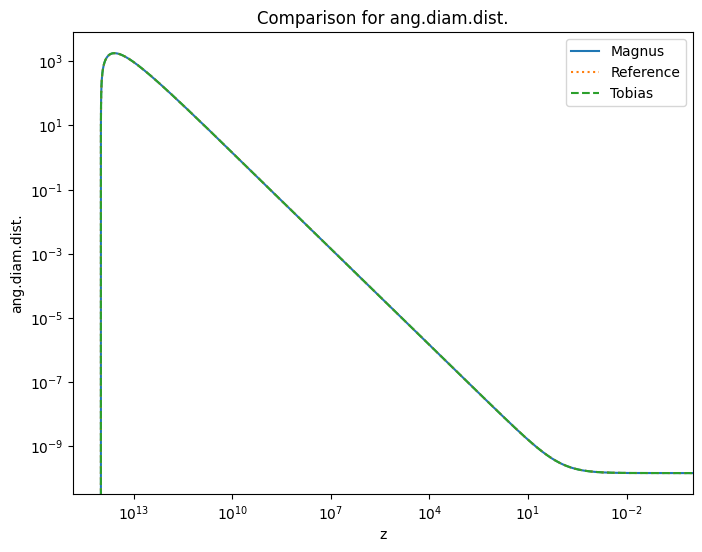

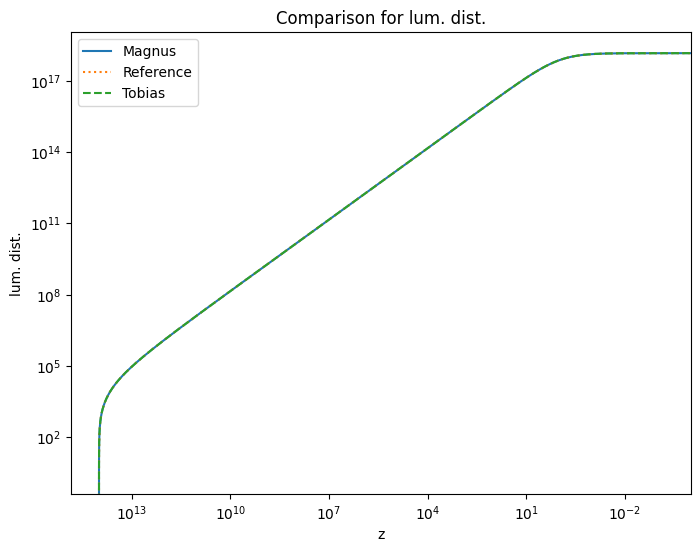

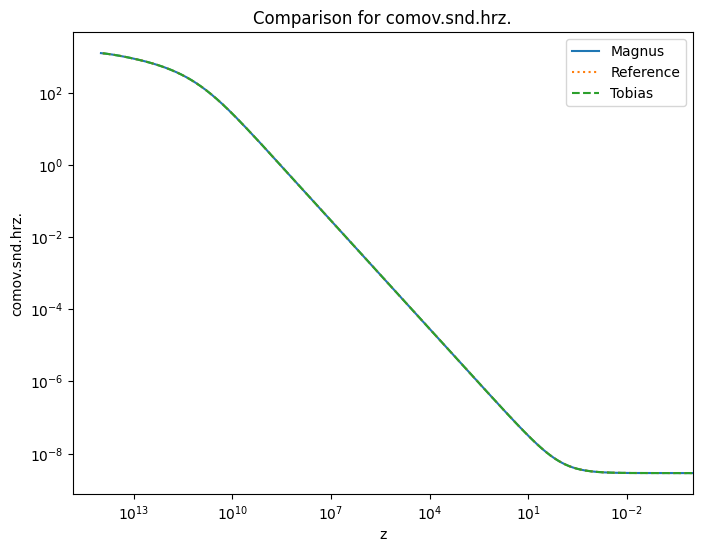

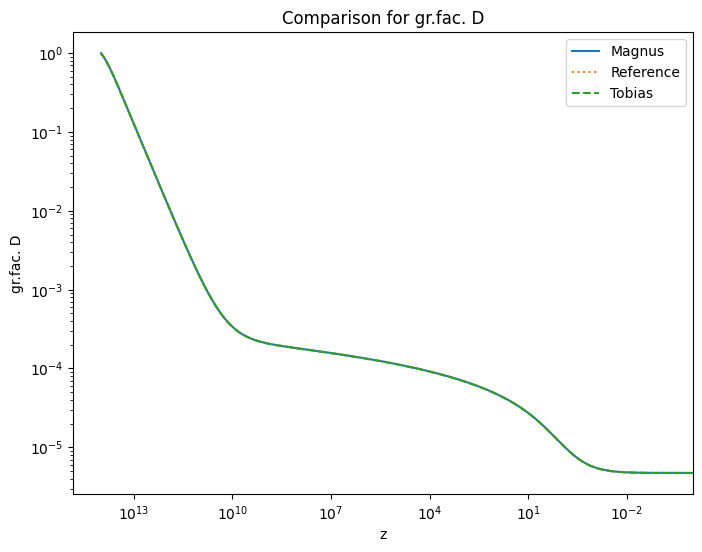

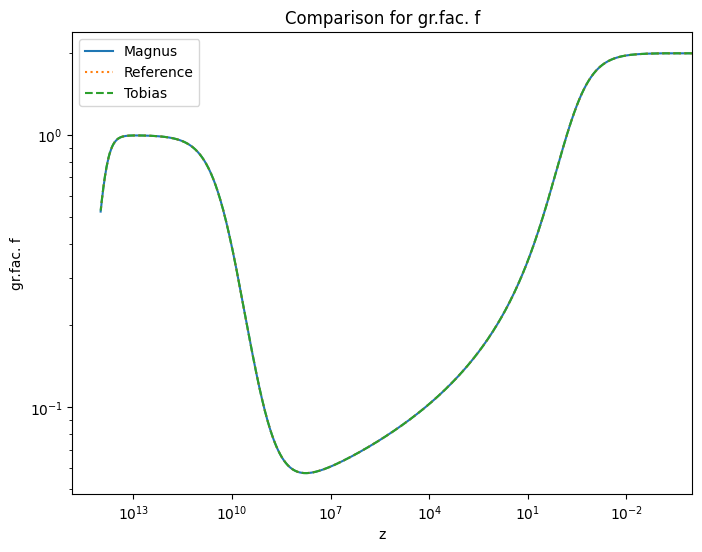

In [7]:
for key in failed_tests.keys():
    print(f"Failed test: {key}")
    print(f"Max Relative Difference: {failed_tests[key]['max_rel_diff']:.2e}") 

    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(z_master, background_Magnus[key], label='Magnus', ls='solid')
    ax.plot(z_master, background_reference[key], label='Reference', ls='dotted')
    ax.plot(z_tobias, background_Tobias[key], label='Tobias', ls='dashed')
    ax.set(xlabel='z', ylabel=key, xscale='log', yscale='log')
    ax.set_title(f'Comparison for {key}')
    ax.legend()

    ax.invert_xaxis()  

DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=0 flag_int=0  Nstd_in=0 Nint_in=0  => Nstd=0 Nint=0 Ntot=0 (local N_ncdm=0)
dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm'])


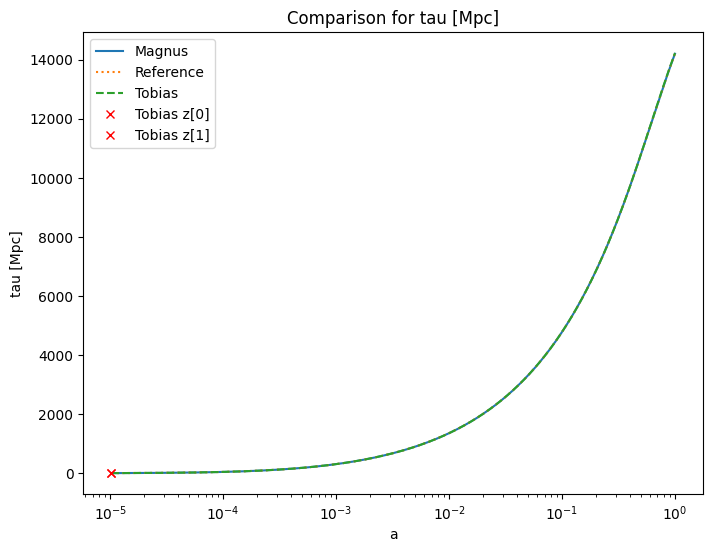

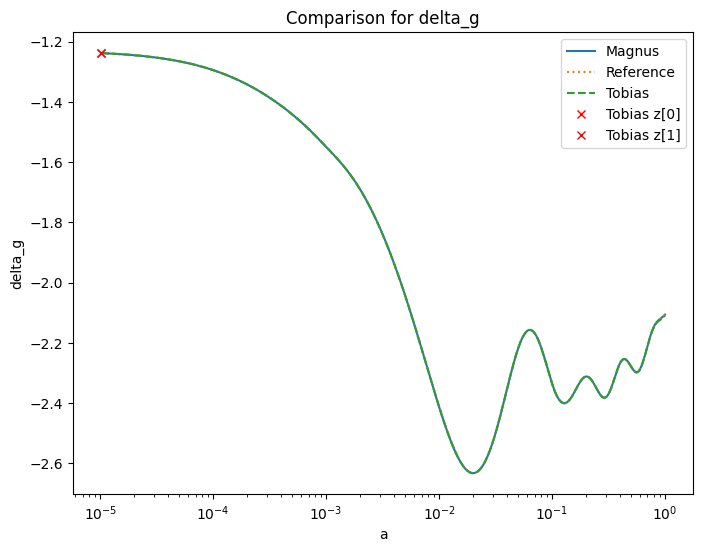

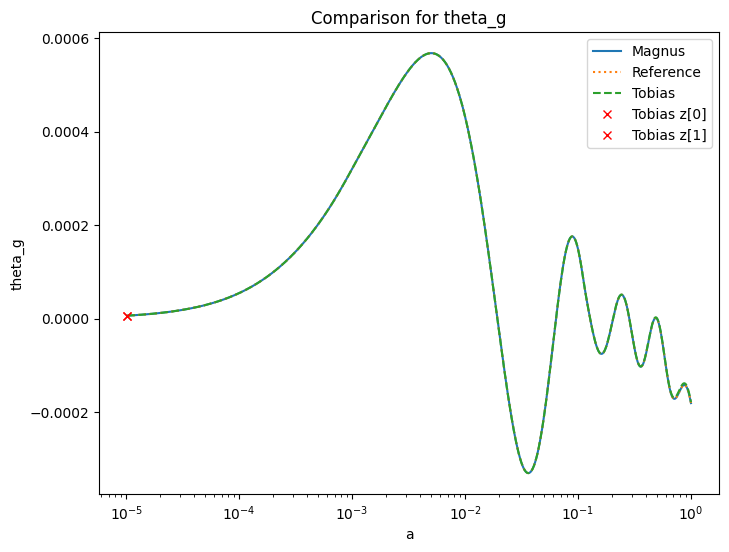

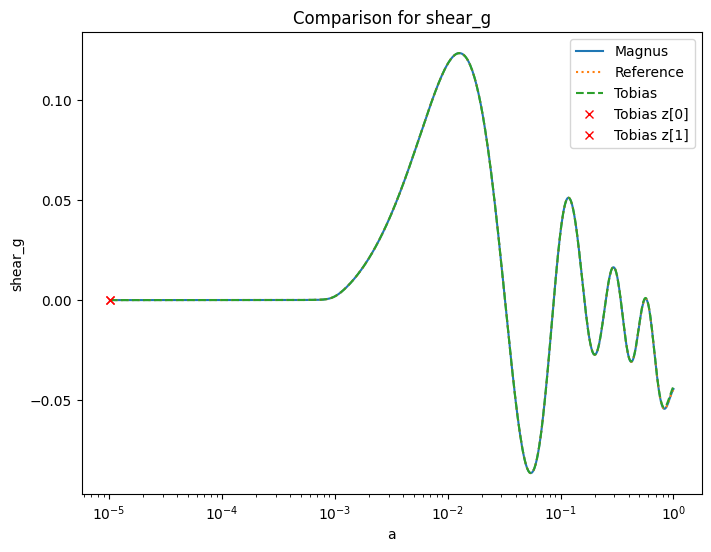

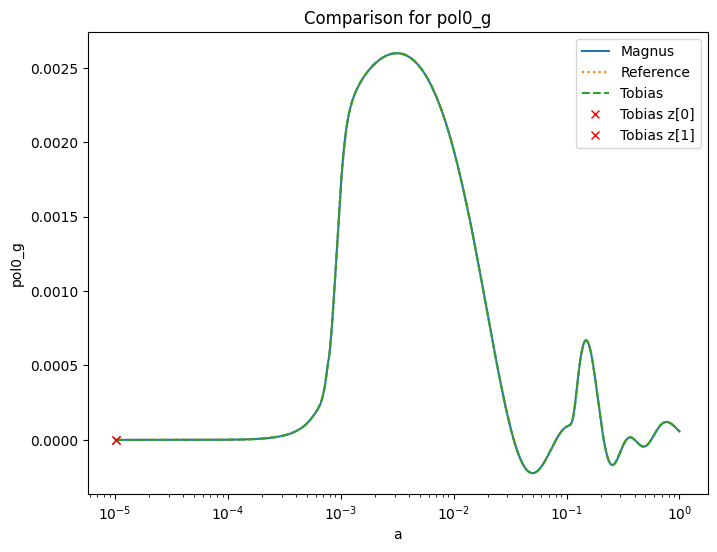

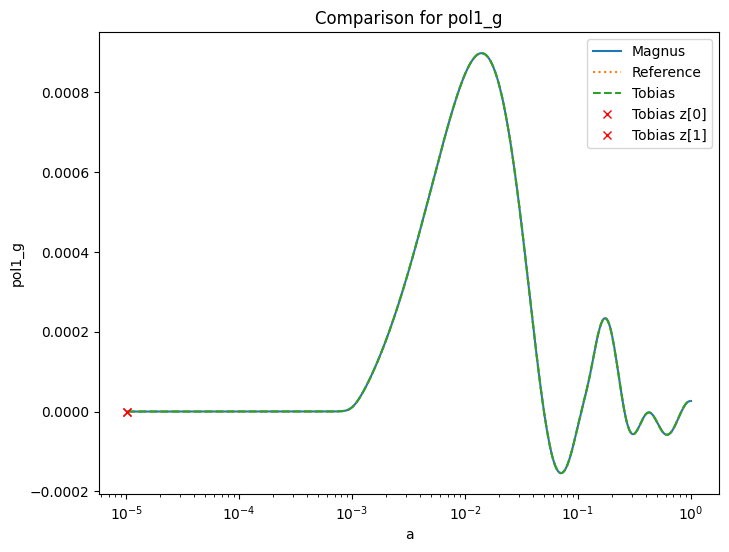

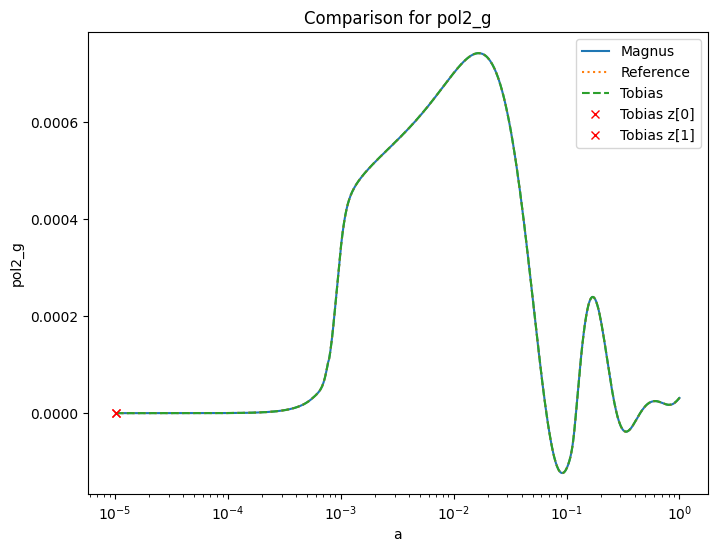

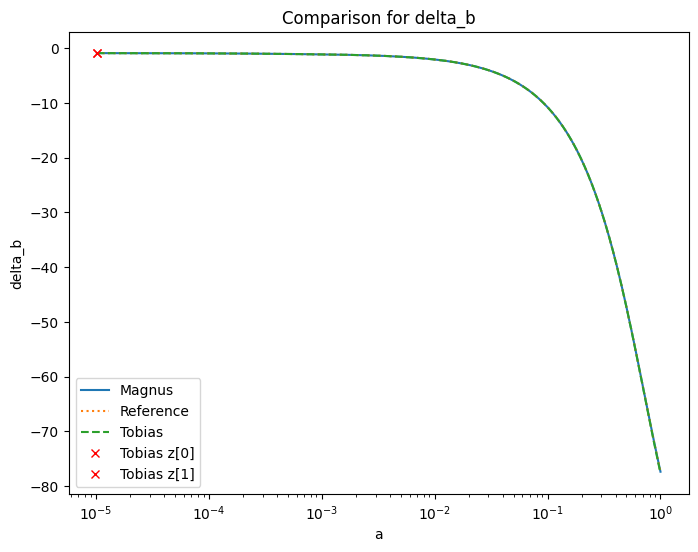

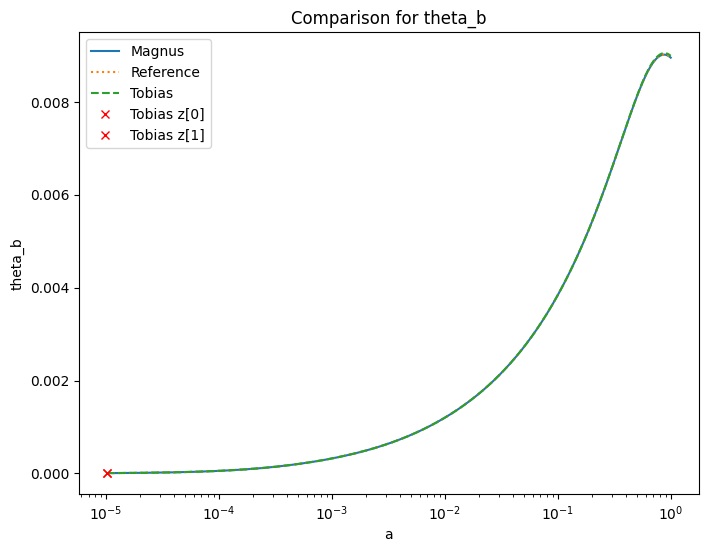

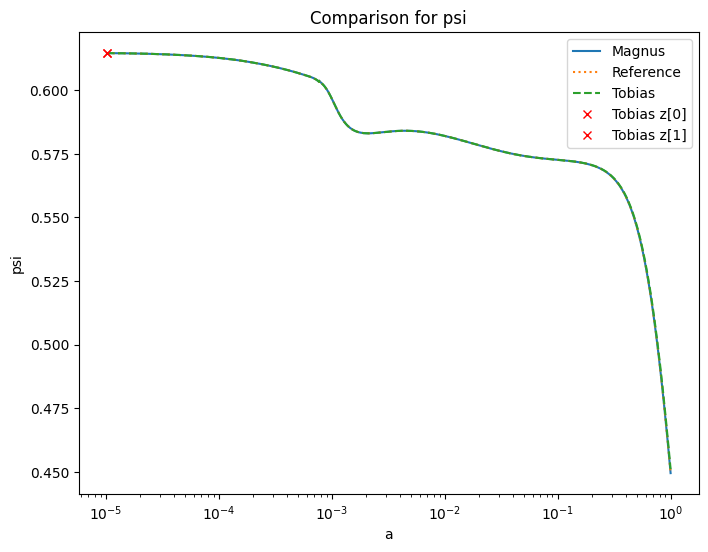

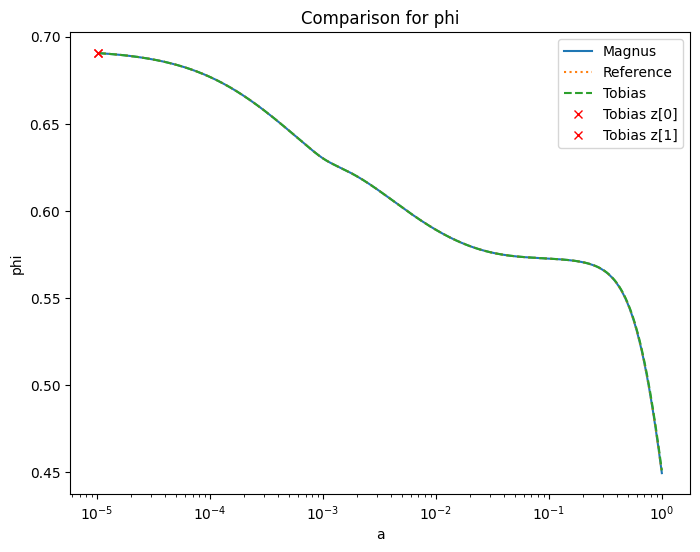

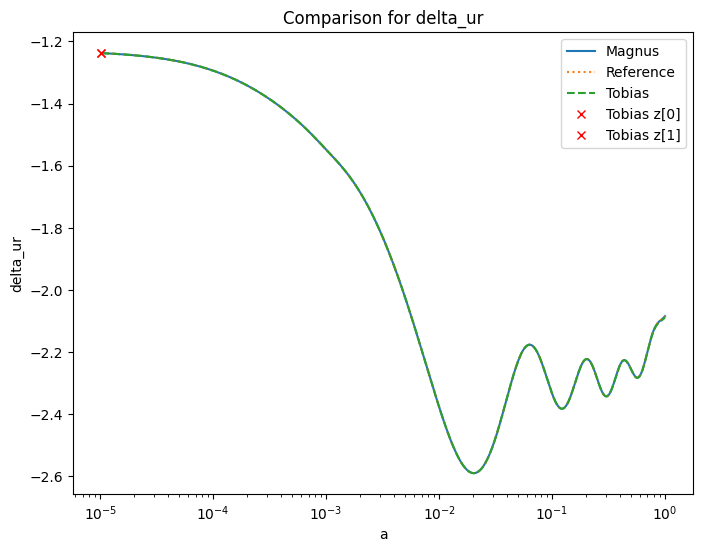

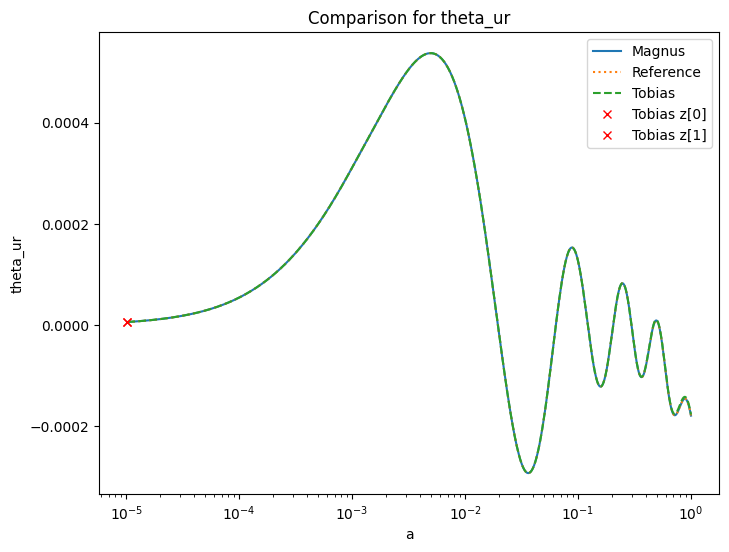

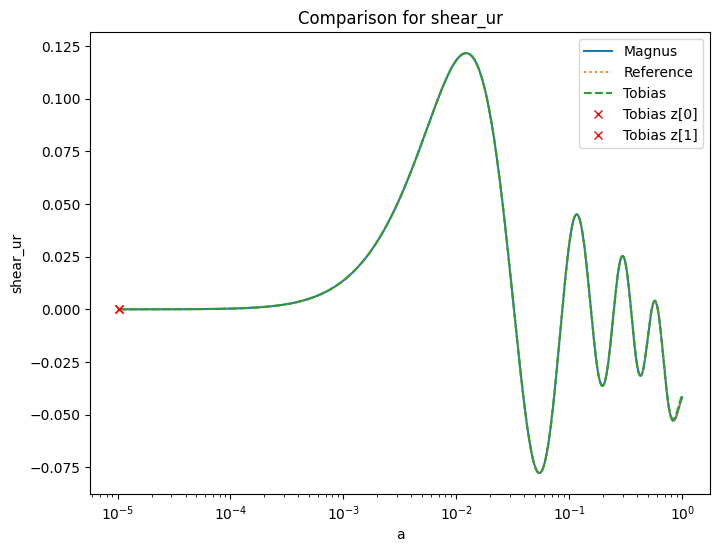

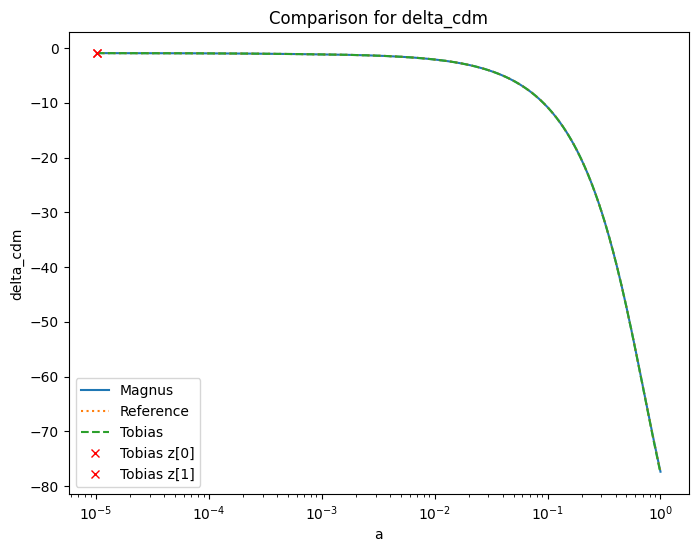

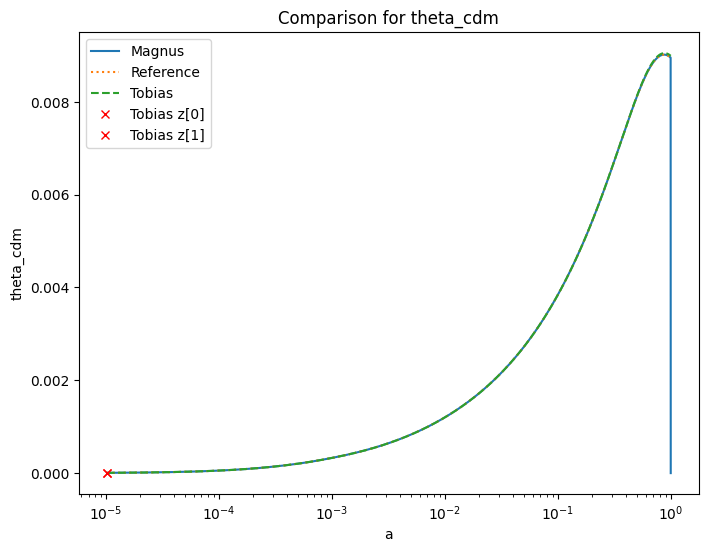

In [8]:
perturbations_Magnus = model_Magnus.get_perturbations()['scalar'][0]
perturbations_Tobias = model_Tobias.get_perturbations()['scalar'][0]
perturbations_reference = model_reference.get_perturbations()['scalar'][0]

a_Magnus = perturbations_Magnus['a']
a_reference = perturbations_reference['a']
a_Tobias = perturbations_Tobias['a']
for key in perturbations_Magnus.keys():
    if key == 'a':
        continue
    

    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(a_Magnus, perturbations_Magnus[key], label='Magnus', ls='solid')
    ax.plot(a_reference, perturbations_reference[key], label='Reference', ls='dotted')
    ax.plot(a_Tobias, perturbations_Tobias[key], label='Tobias', ls='dashed')
    ax.plot(a_Tobias[0], perturbations_Tobias[key][0], 'x', label='Tobias z[0]', color='red') 
    ax.plot(a_Tobias[1], perturbations_Tobias[key][1], 'x', label='Tobias z[1]', color='red')
    ax.set(xlabel='a', ylabel=key, xscale='log')
    #ax.invert_xaxis()  # Invert x-axis to have z decreasing from left to right
    ax.set_title(f'Comparison for {key}')
    ax.legend()

print(perturbations_Magnus.keys())

In [9]:
background_Magnus['(.)p_tot_prime']

array([-1.07542112e+53, -1.07109630e+53, -1.06678886e+53, ...,
       -1.21416110e-15, -1.21077153e-15, -1.20739217e-15], shape=(40000,))

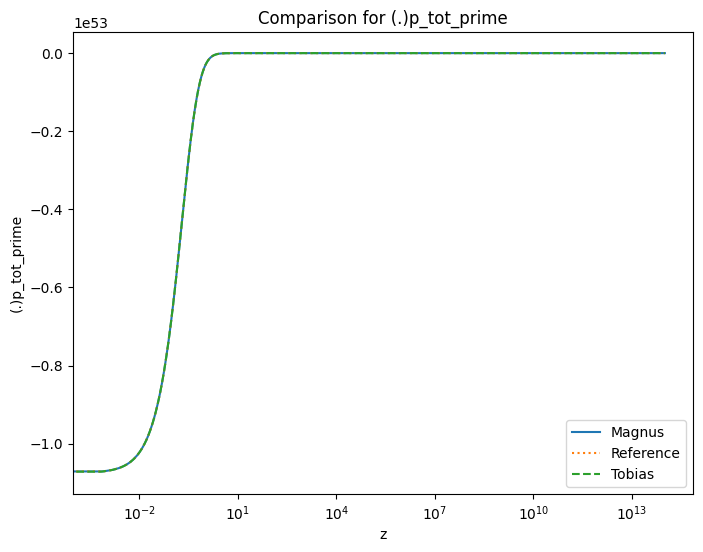

In [10]:
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(z_master, background_Magnus['(.)p_tot_prime'], label='Magnus', ls='solid')
ax.plot(z_master, background_reference['(.)p_tot_prime'], label='Reference', ls='dotted')
ax.plot(z_tobias, background_Tobias['(.)p_tot_prime'], label='Tobias', ls='dashed')
ax.set(xlabel='z', ylabel='(.)p_tot_prime', xscale='log')
ax.set_title(f'Comparison for (.)p_tot_prime')
ax.legend()

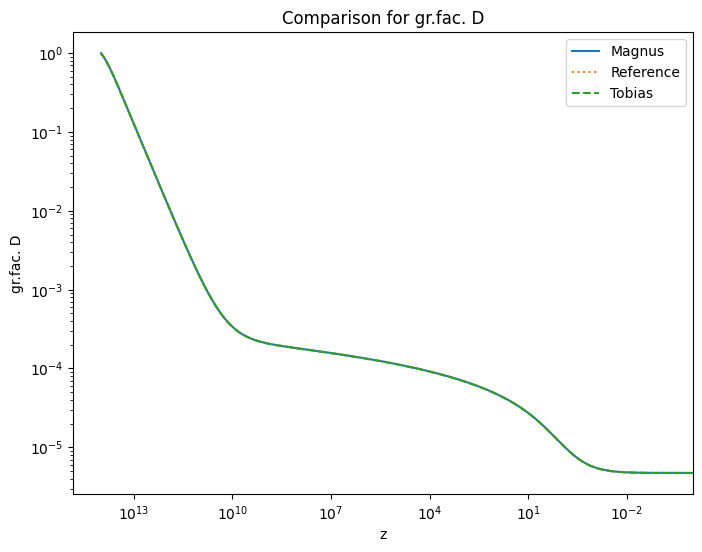

In [11]:
i = 0

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(z_master[i:], background_Magnus['gr.fac. D'][i:], label='Magnus', ls='solid')
ax.plot(z_master[i:], background_reference['gr.fac. D'][i:], label='Reference', ls='dotted')
ax.plot(z_tobias[i:], background_Tobias['gr.fac. D'][i:], label='Tobias', ls='dashed')
ax.set(xlabel='z', ylabel='gr.fac. D', xscale='log', yscale='log')
ax.set_title(f'Comparison for gr.fac. D')
ax.legend()
ax.invert_xaxis()

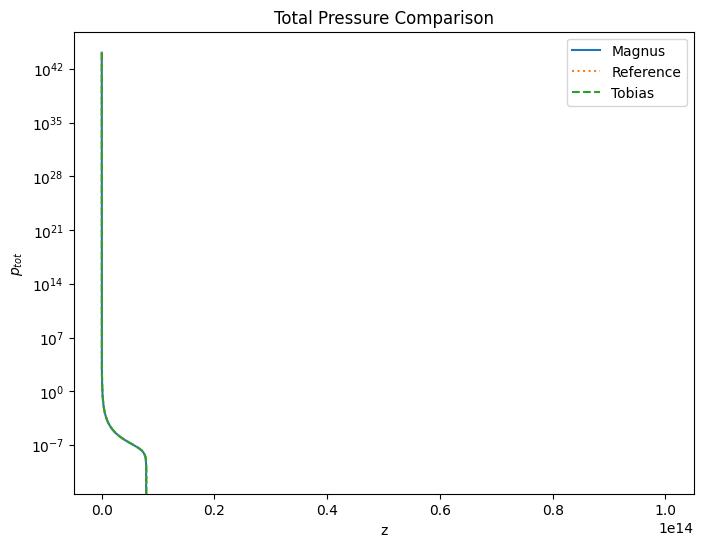

In [12]:
#Plot p_tot:

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(z_master, background_Magnus['(.)p_tot'], label='Magnus', ls='solid')
ax.plot(z_master, background_reference['(.)p_tot'], label='Reference', ls='dotted')
ax.plot(z_tobias, background_Tobias['(.)p_tot'], label='Tobias', ls='dashed')
ax.set(xlabel='z', ylabel=r'$p_{tot}$', yscale='log')
ax.set_title('Total Pressure Comparison')
ax.legend()


DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=0 flag_int=0  Nstd_in=0 Nint_in=0  => Nstd=0 Nint=0 Ntot=0 (local N_ncdm=0)


Text(0.5, 1.0, 'Reference vs Tobias')

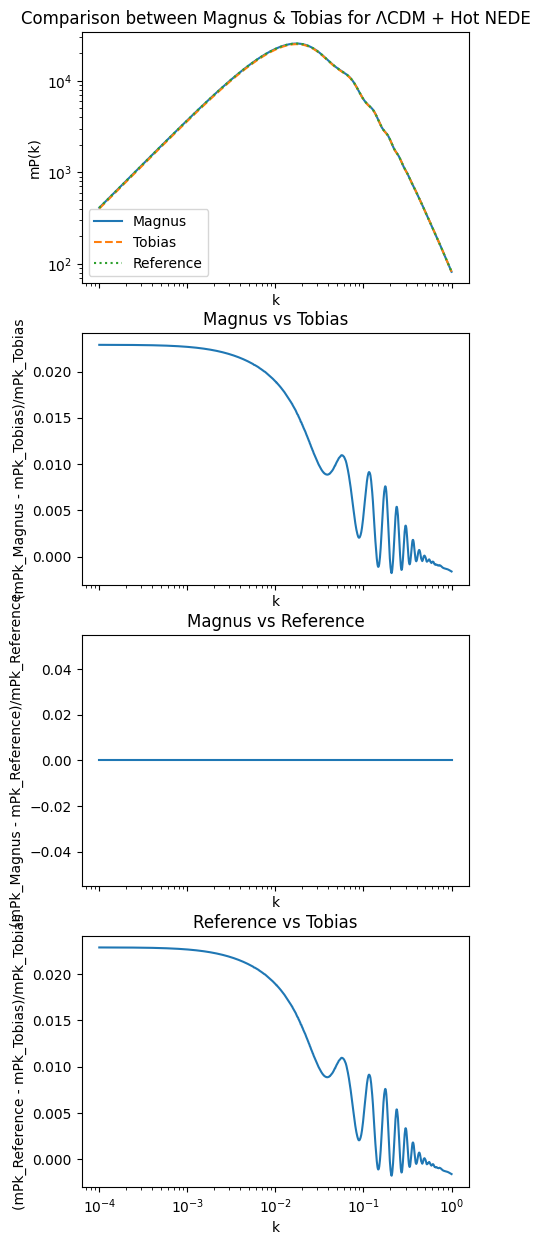

In [13]:
fig, axs = plt.subplots(4,1, figsize=(5,15), sharex=True)

axs[0].set(xscale='log', yscale='log', xlabel="k", ylabel="mP(k)")
axs[0].set_title('Comparison between Magnus & Tobias for ΛCDM + Hot NEDE')

klist_Magnus, mPk_Magnus = plot_mPk(model_Magnus, axs[0], label='Magnus', ls='solid')
klist_Tobias, mPk_Tobias = plot_mPk(model_Tobias, axs[0], label='Tobias', ls='dashed')
klist_Reference, mPk_Reference = plot_mPk(model_reference, axs[0], label='Reference', ls='dotted')
axs[0].legend()

axs[1].plot(klist_Magnus, (mPk_Magnus - mPk_Tobias) / mPk_Tobias)
axs[1].set(xlabel='k', ylabel='(mPk_Magnus - mPk_Tobias)/mPk_Tobias', xscale='log')
axs[1].set_title('Magnus vs Tobias')

axs[2].plot(klist_Magnus, (mPk_Magnus - mPk_Reference) / mPk_Reference)
axs[2].set(xlabel='k', ylabel='(mPk_Magnus - mPk_Reference)/mPk_Reference', xscale='log')
axs[2].set_title('Magnus vs Reference')

axs[3].plot(klist_Tobias, -(mPk_Tobias - mPk_Reference) / mPk_Tobias)
axs[3].set(xlabel='k', ylabel='(mPk_Reference - mPk_Tobias)/mPk_Tobias', xscale='log')
axs[3].set_title('Reference vs Tobias')

DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=0 flag_int=0  Nstd_in=0 Nint_in=0  => Nstd=0 Nint=0 Ntot=0 (local N_ncdm=0)


/tmp/ipykernel_107651/4177948943.py:11: RuntimeWarning: invalid value encountered in divide
  axs[1].plot(l_Magnus, (cl_Magnus - cl_Tobias) / cl_Tobias)
/tmp/ipykernel_107651/4177948943.py:15: RuntimeWarning: invalid value encountered in divide
  axs[2].plot(l_Magnus, (cl_Magnus - cl_Reference) / cl_Reference)
/tmp/ipykernel_107651/4177948943.py:19: RuntimeWarning: invalid value encountered in divide
  axs[3].plot(l_Tobias, -(cl_Tobias - cl_Reference) / cl_Tobias)


Text(0.5, 1.0, 'Reference vs Tobias')

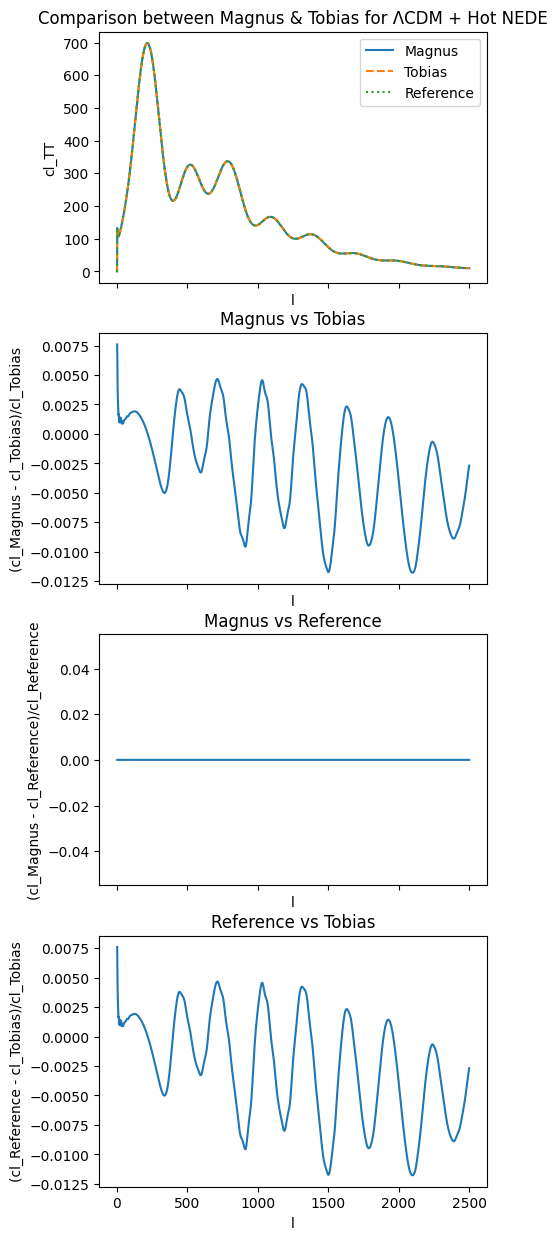

In [14]:
fig, axs = plt.subplots(4,1, figsize=(5,15), sharex=True)

axs[0].set(xlabel="l", ylabel="cl_TT")
axs[0].set_title('Comparison between Magnus & Tobias for ΛCDM + Hot NEDE')

l_Magnus, cl_Magnus = plot_Cl_TT(model_Magnus, axs[0], label='Magnus', ls='solid')
l_Tobias, cl_Tobias = plot_Cl_TT(model_Tobias, axs[0], label='Tobias', ls='dashed')
l_Reference, cl_Reference = plot_Cl_TT(model_reference, axs[0], label='Reference', ls='dotted')
axs[0].legend()

axs[1].plot(l_Magnus, (cl_Magnus - cl_Tobias) / cl_Tobias)
axs[1].set(xlabel='l', ylabel='(cl_Magnus - cl_Tobias)/cl_Tobias')
axs[1].set_title('Magnus vs Tobias')

axs[2].plot(l_Magnus, (cl_Magnus - cl_Reference) / cl_Reference)
axs[2].set(xlabel='l', ylabel='(cl_Magnus - cl_Reference)/cl_Reference')
axs[2].set_title('Magnus vs Reference')

axs[3].plot(l_Tobias, -(cl_Tobias - cl_Reference) / cl_Tobias)
axs[3].set(xlabel='l', ylabel='(cl_Reference - cl_Tobias)/cl_Tobias')
axs[3].set_title('Reference vs Tobias')

/tmp/ipykernel_107651/4016478988.py:12: RuntimeWarning: invalid value encountered in divide
  axs[1].plot(l_Magnus, (cl_Magnus - cl_Tobias) / cl_Tobias)
/tmp/ipykernel_107651/4016478988.py:16: RuntimeWarning: invalid value encountered in divide
  axs[2].plot(l_Magnus, (cl_Magnus - cl_Reference) / cl_Reference)
/tmp/ipykernel_107651/4016478988.py:20: RuntimeWarning: invalid value encountered in divide
  axs[3].plot(l_Tobias, -(cl_Tobias - cl_Reference) / cl_Tobias)


Text(0.5, 1.0, 'Reference vs Tobias')

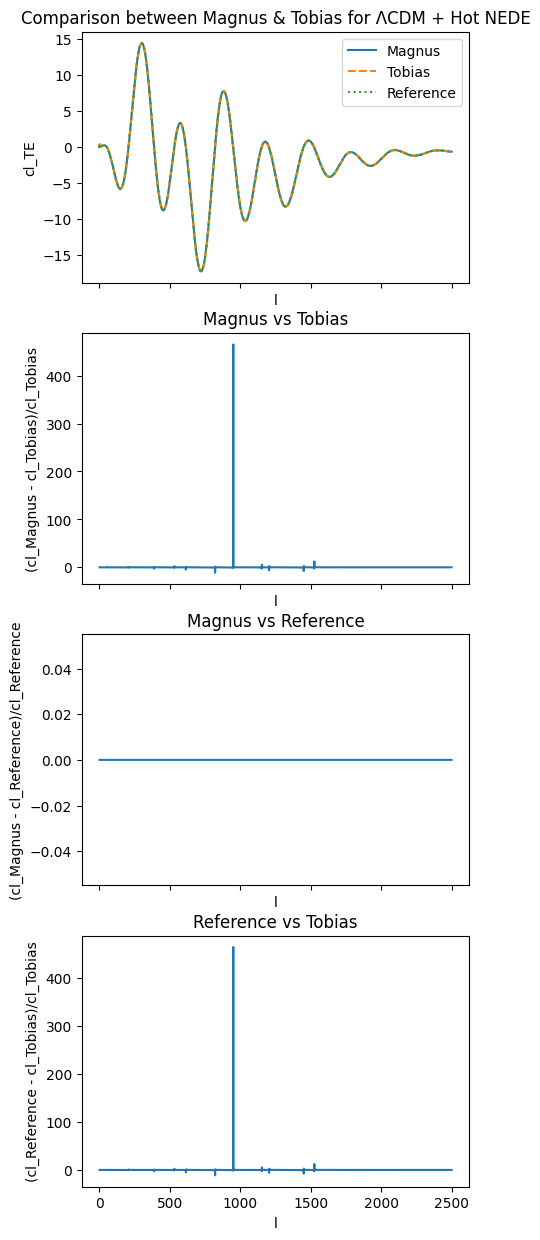

In [15]:
fig, axs = plt.subplots(4,1, figsize=(5,15), sharex=True)

axs[0].set(xlabel="l", ylabel="cl_TE")
axs[0].set_title('Comparison between Magnus & Tobias for ΛCDM + Hot NEDE')


l_Magnus, cl_Magnus = plot_Cl_TE(model_Magnus, axs[0], label='Magnus', ls='solid')
l_Tobias, cl_Tobias = plot_Cl_TE(model_Tobias, axs[0], label='Tobias', ls='dashed')
l_Reference, cl_Reference = plot_Cl_TE(model_reference, axs[0], label='Reference', ls='dotted')
axs[0].legend()

axs[1].plot(l_Magnus, (cl_Magnus - cl_Tobias) / cl_Tobias)
axs[1].set(xlabel='l', ylabel='(cl_Magnus - cl_Tobias)/cl_Tobias')
axs[1].set_title('Magnus vs Tobias')

axs[2].plot(l_Magnus, (cl_Magnus - cl_Reference) / cl_Reference)
axs[2].set(xlabel='l', ylabel='(cl_Magnus - cl_Reference)/cl_Reference')
axs[2].set_title('Magnus vs Reference')

axs[3].plot(l_Tobias, -(cl_Tobias - cl_Reference) / cl_Tobias)
axs[3].set(xlabel='l', ylabel='(cl_Reference - cl_Tobias)/cl_Tobias')
axs[3].set_title('Reference vs Tobias')

/tmp/ipykernel_107651/1206550416.py:12: RuntimeWarning: invalid value encountered in divide
  axs[1].plot(l_Magnus, (cl_Magnus - cl_Tobias) / cl_Tobias)
/tmp/ipykernel_107651/1206550416.py:16: RuntimeWarning: invalid value encountered in divide
  axs[2].plot(l_Magnus, (cl_Magnus - cl_Reference) / cl_Reference)
/tmp/ipykernel_107651/1206550416.py:20: RuntimeWarning: invalid value encountered in divide
  axs[3].plot(l_Tobias, -(cl_Tobias - cl_Reference) / cl_Tobias)


Text(0.5, 1.0, 'Reference vs Tobias')

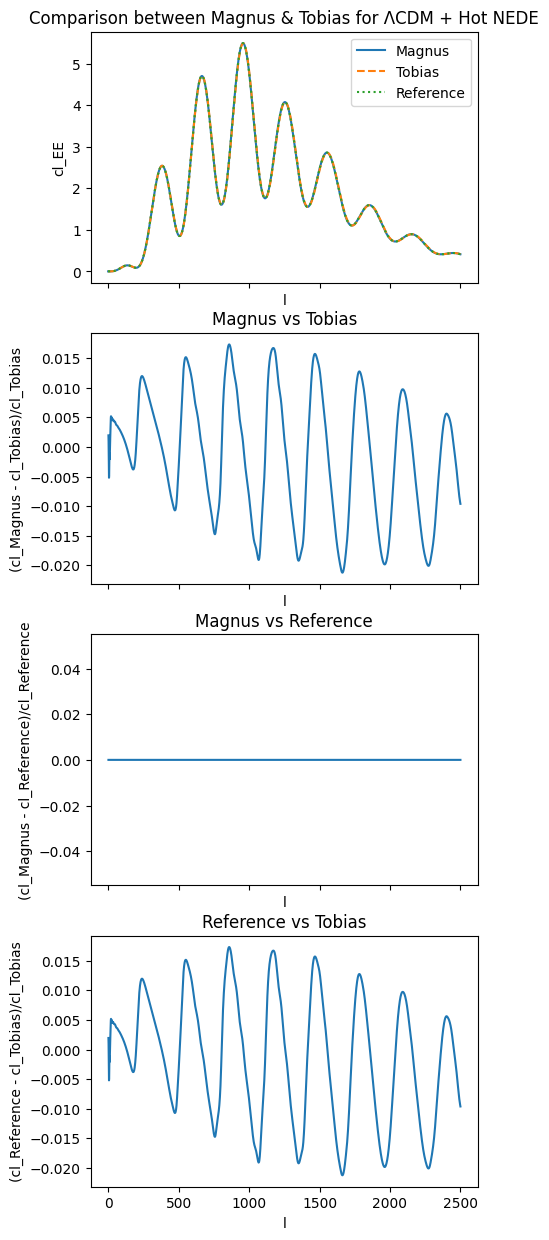

In [16]:
fig, axs = plt.subplots(4,1, figsize=(5,15), sharex=True)

axs[0].set(xlabel="l", ylabel="cl_EE")
axs[0].set_title('Comparison between Magnus & Tobias for ΛCDM + Hot NEDE')


l_Magnus, cl_Magnus = plot_Cl_EE(model_Magnus, axs[0], label='Magnus', ls='solid')
l_Tobias, cl_Tobias = plot_Cl_EE(model_Tobias, axs[0], label='Tobias', ls='dashed')
l_Reference, cl_Reference = plot_Cl_EE(model_reference, axs[0], label='Reference', ls='dotted')
axs[0].legend()

axs[1].plot(l_Magnus, (cl_Magnus - cl_Tobias) / cl_Tobias)
axs[1].set(xlabel='l', ylabel='(cl_Magnus - cl_Tobias)/cl_Tobias')
axs[1].set_title('Magnus vs Tobias')

axs[2].plot(l_Magnus, (cl_Magnus - cl_Reference) / cl_Reference)
axs[2].set(xlabel='l', ylabel='(cl_Magnus - cl_Reference)/cl_Reference')
axs[2].set_title('Magnus vs Reference')

axs[3].plot(l_Tobias, -(cl_Tobias - cl_Reference) / cl_Tobias)
axs[3].set(xlabel='l', ylabel='(cl_Reference - cl_Tobias)/cl_Tobias')
axs[3].set_title('Reference vs Tobias')